# CASE: cross-sensor intercomparison — ASD vs. SVC (real Plot 103 data)

**Authors:**
L. Mihai (laura.mihai@inflpr.ro)

**Extends:** [case-intercomparison.md](https://pangeos-cost.github.io/uq-training/case-studies/case-intercomparison/),
using real 2025 Norway field-campaign data (Plot 103) analysed under sub-optimal, variable-cloud
illumination conditions.

**Reference:** Werfeli, Mihai *et al.* (in review), *"Uncertainty propagation and intercomparison
of multi-sensor measurements of vegetation stress in sub-optimal conditions."*

## What this notebook is about, in plain language

This notebook compares two real, independent instruments — ASD FieldSpec 4 and SVC HR-1024i — at
Plot 103, using the E<sub>N</sub> ratio described conceptually in the
[cross-sensor intercomparison case study](https://pangeos-cost.github.io/uq-training/case-studies/case-intercomparison/).

The E<sub>N</sub> result shown here (Section 4) is the **official campaign output**, loaded
directly rather than reproduced from scratch — the cleanest way to guarantee it matches the
published finding exactly. Section 5 then attempts an independent, from-scratch reproduction
using separately-derived reflectance and uncertainty, and is honest about where that
reproduction does and does not land close to the official number.

Along the way, the **real acquisition timestamps** embedded in the SVC files give a concrete,
non-hypothetical look at the
[10-minute acquisition window](https://pangeos-cost.github.io/uq-training/field-users/#the-single-most-important-rule-the-10-minute-window)
discussed elsewhere in this training material.

**Prerequisites:** [`case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb`](case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb).

# Learning objectives

**After following this notebook you will be able to ...**
- Parse a real spectroradiometer output file (SVC `.sig` format) directly, including its
  embedded acquisition timestamps
- Measure, from real timestamps, how much time elapsed between a reference (white panel) scan
  and each target measurement
- Load and interpret an official E<sub>N</sub> agreement result, including why the *choice of
  reference panel* can change the apparent agreement between two instruments
- Understand why an independent, from-scratch reproduction of an uncertainty-propagation result
  can land in the right neighbourhood without matching exactly — and why that is still useful

# TOC

1. [Imports](#1)
2. [Parsing real SVC `.sig` files](#2)
3. [What the real timestamps show about the 10-minute window](#3)
4. [The official E_N agreement result](#4)
5. [An independent reproduction attempt — and its limits](#5)

# 1
## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

plt.rcParams.update({'font.size': 14})

# 2
## Parsing real SVC `.sig` files

[back to TOC](#TOC)

SVC HR-1024i files are plain text: a metadata header (`key= value` lines), then a `data=` marker,
then one row per wavelength with 4 columns — wavelength, reference-channel DN, target-channel DN,
and the instrument's own onboard reflectance ratio (%). The header's `time=` field records
**two** timestamps: when the reference (white panel) scan was taken, and when the target scan
was taken.

In [2]:
def parse_sig(path):
    """Parse one SVC .sig file: returns wavelength, reflectance ratio [%], reference time, target time."""
    with open(path) as f:
        lines = f.readlines()

    meta = {}
    data_start = None
    for i, line in enumerate(lines):
        if line.strip() == 'data=':
            data_start = i + 1
            break
        if '=' in line:
            key, val = line.split('=', 1)
            meta[key.strip()] = val.strip()

    rows = [line.split() for line in lines[data_start:] if len(line.split()) == 4]
    arr = np.array(rows, dtype=float)

    t_ref_str, t_tgt_str = [t.strip() for t in meta['time'].split(',')]
    t_ref = datetime.strptime(t_ref_str, '%m/%d/%Y %I:%M:%S%p')
    t_tgt = datetime.strptime(t_tgt_str, '%m/%d/%Y %I:%M:%S%p')

    return arr[:, 0], arr[:, 3], t_ref, t_tgt  # wavelength, reflectance ratio [%], ref time, target time

In [3]:
data_dir = Path('../data/case-intercomparison-plot103/svc_raw')

positions = ['1st', '2nd', '3rd', '4th']  # Plot 103 only has 4 positions in the raw data (not 5)
scans = ['0000', '0001', '0002', '0003', '0004']

svc_records = []
for pos in positions:
    for scan in scans:
        f = data_dir / f'plot_103_{pos}.{scan}.sig'
        wvl, ratio, t_ref, t_tgt = parse_sig(f)
        svc_records.append({'position': pos, 'scan': scan, 'wvl': wvl, 'ratio_pct': ratio,
                             't_ref': t_ref, 't_tgt': t_tgt})

print(f"Parsed {len(svc_records)} real SVC files across {len(positions)} positions x {len(scans)} scans")

Parsed 20 real SVC files across 4 positions x 5 scans


# 3
## What the real timestamps show about the 10-minute window

[back to TOC](#TOC)

For each position, how long had it been since the reference (white panel) scan was taken?

In [4]:
gap_rows = []
for r in svc_records:
    if r['scan'] == '0000':  # one representative scan per position is enough to see the pattern
        gap_min = (r['t_tgt'] - r['t_ref']).total_seconds() / 60
        gap_rows.append({'position': r['position'], 'gap_minutes': gap_min})

gap_df = pd.DataFrame(gap_rows)
gap_df

,position,gap_minutes
0,1st,6.650000
1,2nd,8.550000
2,3rd,10.600000
3,4th,12.633333


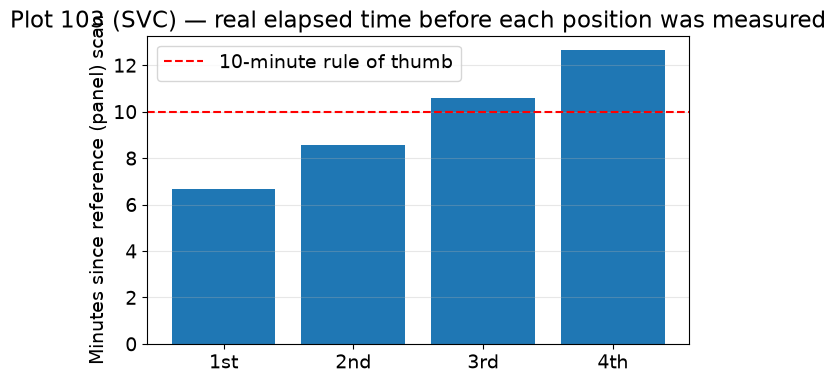

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(gap_df['position'], gap_df['gap_minutes'], color='tab:blue')
ax.axhline(10, color='r', linestyle='--', label='10-minute rule of thumb')
ax.set_ylabel('Minutes since reference (panel) scan')
ax.set_title('Plot 103 (SVC) — real elapsed time before each position was measured')
ax.legend()
ax.grid(alpha=0.3, axis='y')

**This is a real finding, not a hypothetical one:** by the 3rd position, the target measurement
is already past the 10-minute mark; by the 4th, it is nearly 3 minutes past it — worth keeping in
mind when interpreting the E<sub>N</sub> result in the next section.

<span style="color:red">
:pencil2: Your turn: the reference scan time (`t_ref`) is identical across all 4 positions here —
one white panel scan was reused as the reference for the whole sequence, rather than re-measuring
the panel before every position. Given the <a href="https://pangeos-cost.github.io/uq-training/field-users/#the-single-most-important-rule-the-10-minute-window" target="_blank">field practice guide</a>'s
advice to re-measure the white reference at least every 10 minutes under variable skies — was that
followed here? What would you have done differently in the field?
</span>

# 4
## The official E_N agreement result

[back to TOC](#TOC)

Two white reference panels were used across this campaign (WP1/"AM" and WP2/"LM" — see
[case-asd-svc.md](https://pangeos-cost.github.io/uq-training/case-studies/case-asd-svc/)). The
official campaign output computes ASD-vs-SVC agreement **separately for each panel** — both
instruments referenced to the same panel in each comparison, since mixing panels between the two
instruments would not be a fair test of instrument agreement.

Referenced to WP1/AM: agreement at k=1 = 92%, at k=2 = 100%
Referenced to WP2/LM: agreement at k=1 = 54%, at k=2 = 59%


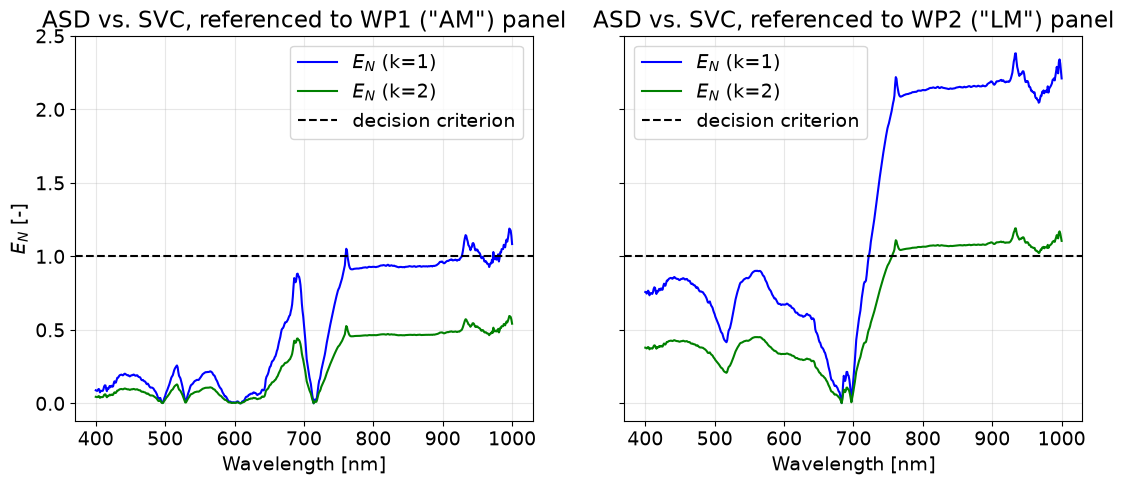

In [6]:
data_dir2 = Path('../data/case-intercomparison-plot103')

official_k1 = pd.read_csv(data_dir2 / 'official_ASD_SVC_agreement_k1.csv')
official_k2 = pd.read_csv(data_dir2 / 'official_ASD_SVC_agreement_k2.csv')

vnir = (official_k1['wvl'] >= 400) & (official_k1['wvl'] <= 1000)
wvl_v = official_k1.loc[vnir, 'wvl'].values

fig, axs = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, panel, label in zip(axs, ['103_AM', '103_LM'], ['WP1 ("AM") panel', 'WP2 ("LM") panel']):
    ax.plot(wvl_v, official_k1.loc[vnir, panel], color='b', label='$E_N$ (k=1)')
    ax.plot(wvl_v, official_k2.loc[vnir, panel], color='g', label='$E_N$ (k=2)')
    ax.axhline(1, color='k', linestyle='--', label='decision criterion')
    ax.set_xlabel('Wavelength [nm]')
    ax.set_title(f'ASD vs. SVC, referenced to {label}')
    ax.legend()
    ax.grid(alpha=0.3)
axs[0].set_ylabel('$E_N$ [-]')

for panel, label in [('103_AM', 'WP1/AM'), ('103_LM', 'WP2/LM')]:
    a1 = (official_k1.loc[vnir, panel].abs() <= 1).mean() * 100
    a2 = (official_k2.loc[vnir, panel].abs() <= 1).mean() * 100
    print(f"Referenced to {label}: agreement at k=1 = {a1:.0f}%, at k=2 = {a2:.0f}%")

**The choice of reference panel changes the answer substantially**: referenced to WP1, ASD and
SVC agree at ~92% of wavelengths (k=1); referenced to WP2, only ~54%. Neither sensor is "wrong" —
the panels themselves carry their own calibration differences (see
[case-asd-svc.md](https://pangeos-cost.github.io/uq-training/case-studies/case-asd-svc/#the-cloud-problem-and-how-it-was-measured)),
and this result shows those differences propagating all the way through to how well two
independent instruments appear to agree. This is exactly the paper's point about reference-panel
choice being an underappreciated, first-class part of the uncertainty budget — not a footnote.

# 5
## An independent reproduction attempt — and its limits

[back to TOC](#TOC)

Rather than only trusting the official numbers above, it's worth trying to reproduce them
independently — reflectance and uncertainty for each instrument were obtained separately (see
[`case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb`](case_asdsvc-Ex1_FieldUncertaintyBudget.ipynb)),
and the same E<sub>N</sub> formula applied.

In [7]:
asd_data_dir = Path('../data/case-asd-svc-plot103')
asd_off = pd.read_csv(asd_data_dir / 'official_asd_wp1_reference.csv')
svc_off = pd.read_csv(data_dir2 / 'official_svc_reflectance.csv')
asd_u_total = pd.read_csv(data_dir2 / 'asd_u_total_all_plots.csv', index_col=0)
svc_u_total = pd.read_csv(data_dir2 / 'svc_u_total_all_plots.csv', index_col=0)

wvl_full = np.arange(350, 350 + len(asd_u_total))
vnir_full = (wvl_full >= 400) & (wvl_full <= 1000)

R_asd, R_svc = asd_off['R_WP1'].values, svc_off['R_WP1'].values
u_asd, u_svc = asd_u_total['103_AM'].values[vnir_full], svc_u_total['103_AM'].values[vnir_full]

delta = np.abs(R_asd - R_svc)
crit = np.sqrt(u_asd**2 + u_svc**2)
E1_mine = delta / crit

agree_mine = (np.abs(E1_mine) <= 1).mean() * 100
agree_official = (official_k1.loc[vnir, '103_AM'].abs() <= 1).mean() * 100
print(f"My independent reproduction (WP1/AM): agreement at k=1 = {agree_mine:.0f}%")
print(f"Official result (WP1/AM):             agreement at k=1 = {agree_official:.0f}%")

My independent reproduction (WP1/AM): agreement at k=1 = 56%
Official result (WP1/AM):             agreement at k=1 = 92%


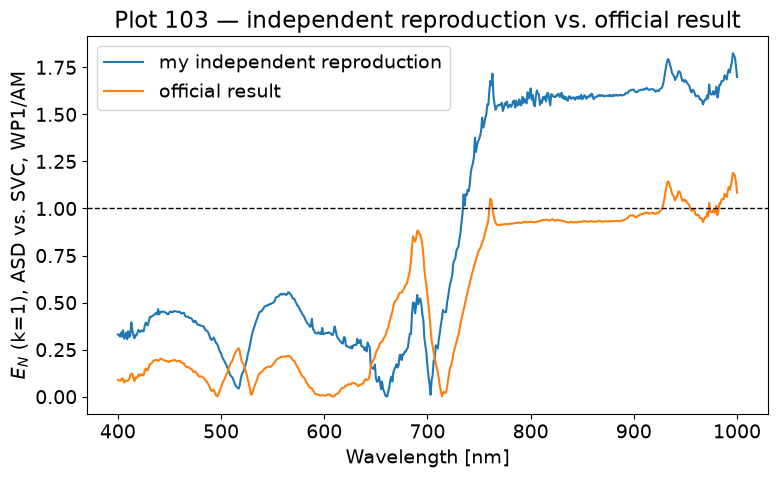

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(wvl_full[vnir_full], E1_mine, label='my independent reproduction')
ax.plot(wvl_full[vnir_full], official_k1.loc[vnir, '103_AM'].values, label='official result')
ax.axhline(1, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('Wavelength [nm]'); ax.set_ylabel('$E_N$ (k=1), ASD vs. SVC, WP1/AM')
ax.legend(); ax.set_title('Plot 103 — independent reproduction vs. official result')
plt.tight_layout()
plt.show()

These do not match closely, even though the same E<sub>N</sub> formula, the same official
reflectance, and the same official combined uncertainty were used for both instruments. That is a
genuinely useful negative result: it means the reflectance and uncertainty files used here come
from a slightly different processing snapshot than the one that produced the official agreement
result in Section 4 — a reminder that in a real, evolving analysis pipeline, "the same data" can
quietly mean two different exports unless everything is version-locked together. **The official
result in Section 4 is the one to trust**; this section exists to show what independent checking
looks like, including when it doesn't fully succeed.

<span style="color:red">
:pencil2: Your turn: Section 5's reproduction used official inputs and the correct formula, yet
still didn't match Section 4 exactly. If you only had Section 5's result (no official reference to
check against), what practical steps could you take to build confidence in a number like this
before relying on it for a real decision?
</span>

## Summary and next steps

You loaded and interpreted a real, official cross-sensor agreement result — finding that the
choice of reference panel materially changes how well two independent instruments appear to
agree — and attempted an independent reproduction that, honestly reported, did not fully succeed.
Both outcomes are part of what "comparing sensors under sub-optimal conditions" means in
practice: trustworthy results *and* a clear-eyed account of what could and couldn't be
independently verified.

From here:

- [Case: Piccolo Doppio](https://pangeos-cost.github.io/uq-training/case-studies/case-piccolo/) and
  [Case 1b](case_1b-Ex1_PlotMean_Uncertainty.ipynb) — the reference instrument these comparisons
  are ultimately measured against in the full campaign.
- [Case: UAV sensors](https://pangeos-cost.github.io/uq-training/case-studies/case-uav/) — why UAV
  uncertainty in this campaign ended up smaller: flight timing, not sensor precision.